In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv(r"C:\Users\91628\Downloads\bank-additional-full.csv.zip", sep=';')
print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [17]:
print("standard nulls per column: ")
print(df.isnull().sum())

standard nulls per column: 
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [19]:

cat_col=df.select_dtypes(include='object').columns

for c in cat_col:
    n_unknown=(df[c]=='unknown').sum()

    if n_unknown>0:
        pct=n_unknown/len(df)*100
        print(f"{c}: {n_unknown} unknowns ({pct:1f}%)")


job: 330 unknowns (0.801204%)
marital: 80 unknowns (0.194231%)
education: 1731 unknowns (4.202680%)
default: 8597 unknowns (20.872584%)
housing: 990 unknowns (2.403613%)
loan: 990 unknowns (2.403613%)


C:\Users\91628\AppData\Local\Temp\ipykernel_4740\2544586319.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=df.select_dtypes(include='object').columns


In [20]:
print("full duplicated row: ", df.duplicated().sum())

full duplicated row:  12


y
no     35377
yes     4496
Name: count, dtype: int64
y
no     88.724199
yes    11.275801
Name: proportion, dtype: float64


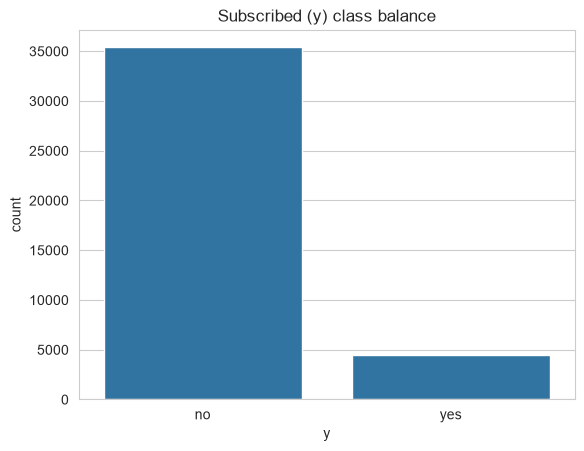

In [46]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True)*100)

sns.countplot(x='y',data=df)
plt.title('Subscribed (y) class balance')
plt.show()

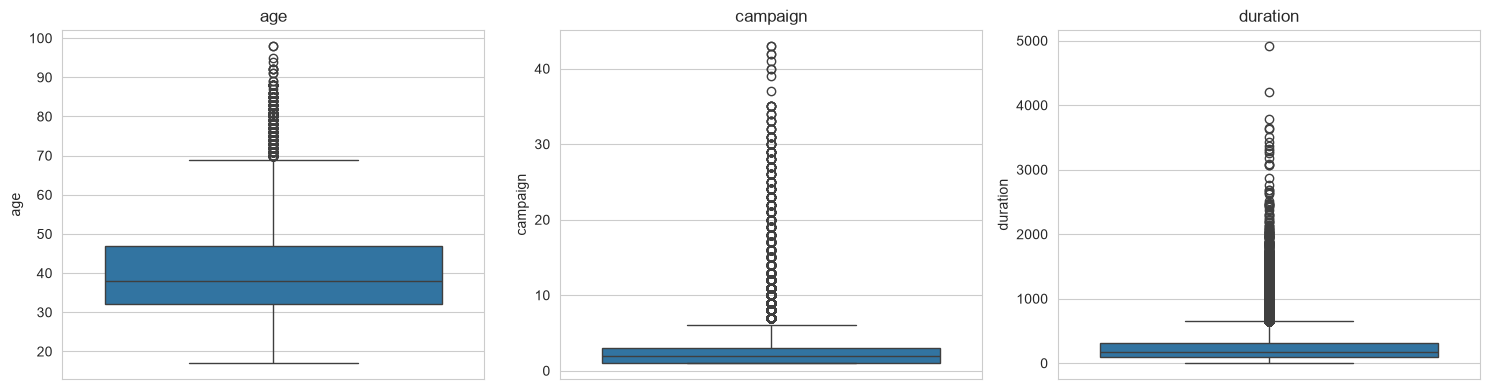

In [47]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax ,col in zip(axes,['age','campaign','duration']):
    sns.boxplot(y=df[col],ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
print(df['pdays'].describe())
print()
print("Most common pdays values:")
print(df['pdays'].value_counts().head())

count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

Most common pdays values:
pdays
999    39673
3        439
6        412
4        118
9         64
Name: count, dtype: int64


In [7]:
print(df['previous'].describe())

count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64


In [23]:
columns_unknown=['job','marital','education','default','housing','loan']
rows_before=len(df)
rows_if_unknown_droped=len(df[~(df[columns_unknown]=='unknown').any(axis=1)])
print(f"number of row before droping unknown : {rows_before}")
print(f"number of row after droping unknown : {rows_if_unknown_droped}")
print(f"number of rows lost:{rows_before-rows_if_unknown_droped} ({(rows_before - rows_if_unknown_droped)/rows_before*100:.1f}%)")

number of row before droping unknown : 41188
number of row after droping unknown : 30488
number of rows lost:10700 (26.0%)


In [24]:
before=len(df)
df=df.drop_duplicates()
after=len(df)
print(f"number of rows after deleting duplicate row: {rows_before - after}")
print(f"new shape id: {df.shape}")
# total 12 rows were deleted but i ran the command twice so second time there was no duplicate row to delete from so used rows_before from up

number of rows after deleting duplicate row: 12
new shape id: (41176, 21)


In [25]:
default_unknown_subscribe_rate=df[df['default']=='unknown']['y'].value_counts(normalize=True)
overall_subscribe_rate=df['y'].value_counts(normalize=True)
print("subscibe rate when default status id js unknown:")
print(default_unknown_subscribe_rate*100)
print("overall subscribe rate:")
print(overall_subscribe_rate*100)

subscibe rate when default status id unknown:
y
no     94.84644
yes     5.15356
Name: proportion, dtype: float64
overall subscribe rate:
y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


In [8]:
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
overall_rate = (df['y']=='yes').mean()*100

print(f"Overall subscribe rate: {overall_rate:.2f}%")
print()

for c in cols_with_unknown:
    unknown_rate = (df[df[c]=='unknown']['y']=='yes').mean()*100
    n_unknown = (df[c]=='unknown').sum()
    if n_unknown > 0:
        diff = unknown_rate - overall_rate
        print(f"{c:12s}: {n_unknown:5d} unknowns -> subscribe rate {unknown_rate:5.2f}%  (diff from avg: {diff:+.2f}pp) ")

Overall subscribe rate: 11.27%

job         :   330 unknowns -> subscribe rate 11.21%  (diff from avg: -0.05pp) 
marital     :    80 unknowns -> subscribe rate 15.00%  (diff from avg: +3.73pp) 
education   :  1731 unknowns -> subscribe rate 14.50%  (diff from avg: +3.23pp) 
default     :  8597 unknowns -> subscribe rate  5.15%  (diff from avg: -6.11pp) 
housing     :   990 unknowns -> subscribe rate 10.81%  (diff from avg: -0.46pp) 
loan        :   990 unknowns -> subscribe rate 10.81%  (diff from avg: -0.46pp) 


In [9]:
before = len(df)
df = df[(df['job'] != 'unknown') & (df['housing'] != 'unknown') & (df['loan'] != 'unknown')]
after = len(df)
print(f"Dropped {before - after} rows ({(before-after)/before*100:.2f}% of data)")
print(f"New shape: {df.shape}")

Dropped 1315 rows (3.19% of data)
New shape: (39873, 21)


job
student          30.99
retired          25.30
unemployed       14.49
admin.           12.98
management       11.36
technician       10.75
self-employed    10.64
housemaid         9.99
entrepreneur      8.52
services          8.17
blue-collar       6.90
Name: y, dtype: float64


C:\Users\91628\AppData\Local\Temp\ipykernel_41536\3328832194.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


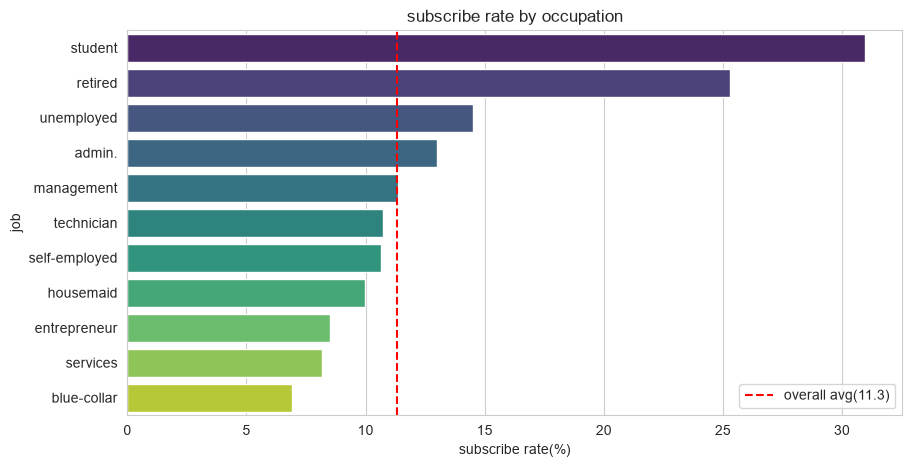

In [48]:
occupation_to_subscribe=df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(occupation_to_subscribe.round(2))
plt.figure(figsize=(10,5))
sns.barplot(
    x=occupation_to_subscribe.values,
    y=occupation_to_subscribe.index,
    palette='viridis'
)
plt.xlabel('subscribe rate(%)')
plt.title('subscribe rate by occupation')
plt.axvline(11.3,color='red',linestyle='--',label='overall avg(11.3)')
plt.legend()
plt.savefig('subscribe rate by occupation', dpi=300, bbox_inches='tight')
plt.show()

    

education
illiterate             22.222222
unknown                14.660691
university.degree      13.715395
professional.course    11.320016
high.school            10.887881
basic.4y               10.306963
basic.6y                8.144796
basic.9y                7.827422
Name: y, dtype: float64 2


C:\Users\91628\AppData\Local\Temp\ipykernel_41536\3598005191.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


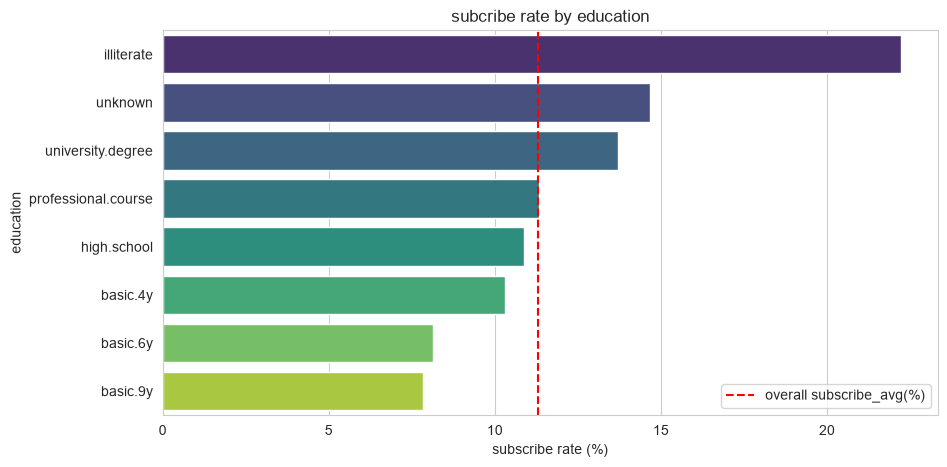

In [49]:
education_rate=df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(education_rate,round(2))
plt.figure(figsize=(10,5))
sns.barplot(
    x=education_rate.values,
    y=education_rate.index,
    palette='viridis'

)
plt.xlabel('subscribe rate (%)')
plt.title('subcribe rate by education')
plt.axvline(11.3,color='red',linestyle='--',label='overall subscribe_avg(%)')
plt.legend()
plt.savefig('subscribe rate by education', dpi=300, bbox_inches='tight')
plt.show()
            

age_band
18-30    15.03
31-40     9.81
41-50     8.18
51-60    10.68
60+      45.45
Name: y, dtype: float64


C:\Users\91628\AppData\Local\Temp\ipykernel_41536\4211081273.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_rate.index, y=age_rate.values, palette='viridis')


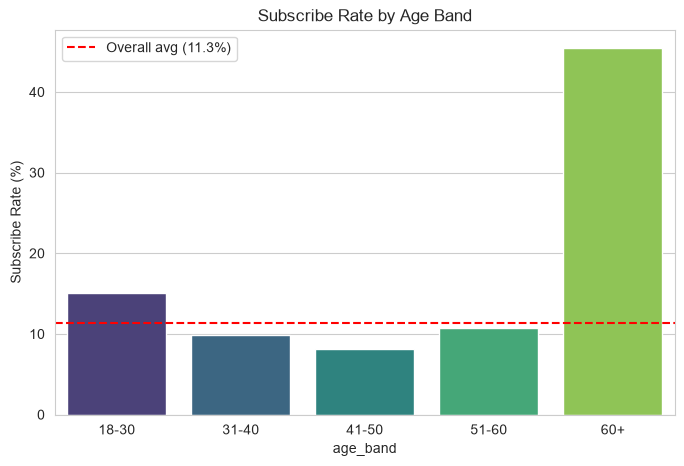

In [50]:
df['age_band'] = pd.cut(df['age'], bins=[18,30,40,50,60,100],
                          labels=['18-30','31-40','41-50','51-60','60+'])

age_rate = df.groupby('age_band', observed=True)['y'].apply(lambda x: (x=='yes').mean()*100)
print(age_rate.round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=age_rate.index, y=age_rate.values, palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Age Band')
plt.axhline(11.3, color='red', linestyle='--', label='Overall avg (11.3%)')
plt.legend()
plt.savefig('subscribe rate by age_band', dpi=300, bbox_inches='tight')
plt.show()

marital
single      13.96
unknown     12.86
divorced    10.38
married     10.19
Name: y, dtype: float64


C:\Users\91628\AppData\Local\Temp\ipykernel_41536\3030027665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_rate.index, y=marital_rate.values, palette='viridis')


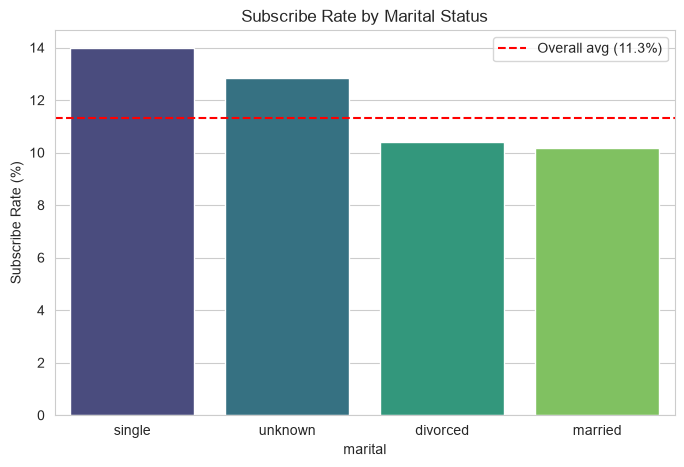

In [51]:
marital_rate = df.groupby('marital')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(marital_rate.round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=marital_rate.index, y=marital_rate.values, palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Marital Status')
plt.axhline(11.3, color='red', linestyle='--', label='Overall avg (11.3%)')
plt.legend()
plt.savefig('subscribe rate by marital_status', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\91628\AppData\Local\Temp\ipykernel_41536\2384047109.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=housing_rate.index, y=housing_rate.values, ax=axes[0], palette='viridis')
C:\Users\91628\AppData\Local\Temp\ipykernel_41536\2384047109.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loan_rate.index, y=loan_rate.values, ax=axes[1], palette='viridis')


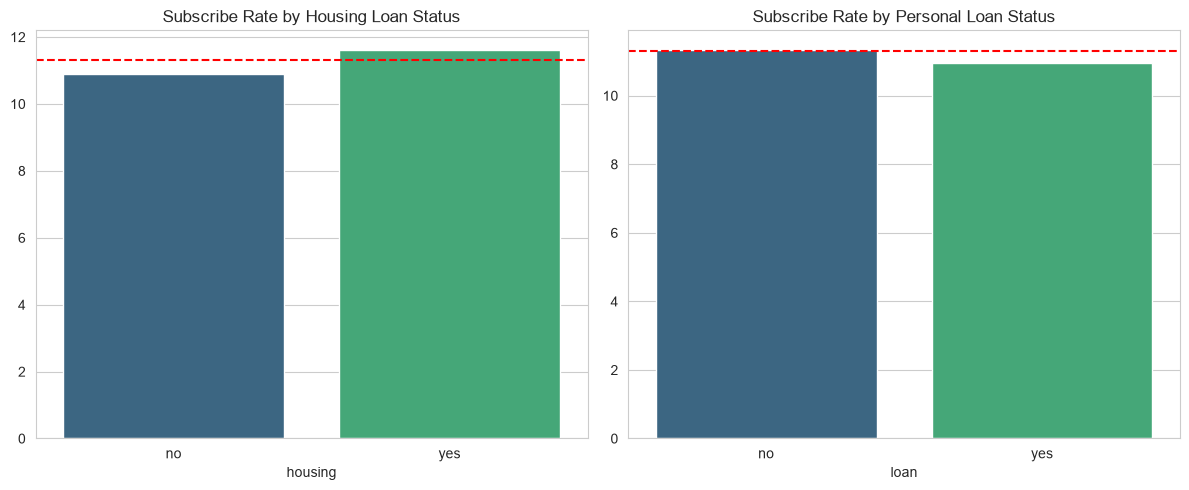

In [52]:
housing_rate = df.groupby('housing')['y'].apply(lambda x: (x=='yes').mean()*100)
loan_rate = df.groupby('loan')['y'].apply(lambda x: (x=='yes').mean()*100)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(x=housing_rate.index, y=housing_rate.values, ax=axes[0], palette='viridis')
axes[0].set_title('Subscribe Rate by Housing Loan Status')
axes[0].axhline(11.3, color='red', linestyle='--')

sns.barplot(x=loan_rate.index, y=loan_rate.values, ax=axes[1], palette='viridis')
axes[1].set_title('Subscribe Rate by Personal Loan Status')
axes[1].axhline(11.3, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('subscribe rate by housing and loan', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
combo1=df.groupby(['age_band','job'],observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()
reliable_combo=combo1[combo1['group_size']>=100].sort_values('subscribe_rate',ascending=False)
print(reliable_combo.head(15).to_string(index=False))

age_band           job  subscribe_rate  group_size
     60+       retired       46.142209         661
   18-30       student       32.408759         685
   31-40       student       21.374046         131
   18-30    unemployed       21.341463         164
   51-60    unemployed       17.482517         143
   18-30        admin.       17.141500        2106
   18-30 self-employed       15.354331         254
   18-30    management       15.057915         259
   51-60        admin.       14.383562        1168
   31-40    unemployed       13.486005         393
   18-30    technician       13.333333        1140
   51-60       retired       12.374582         897
   31-40    management       11.581921        1062
   31-40        admin.       11.306257        4555
   51-60    management       11.217949         624


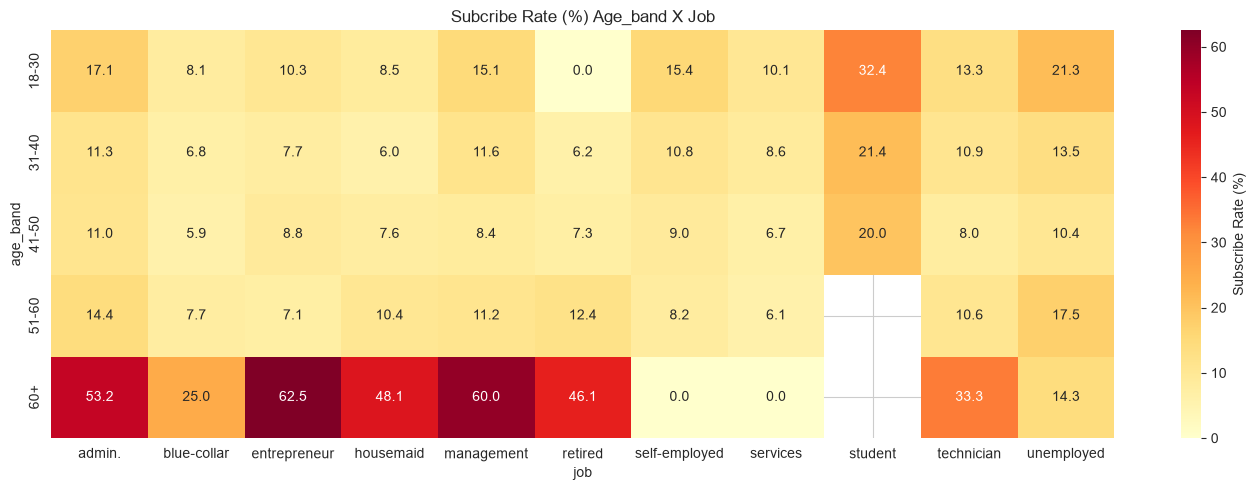

In [53]:
pivot=df.pivot_table(
    values='y',
    index='age_band',
    columns='job',
    aggfunc=lambda x:(x=='yes').mean()*100,
    observed=True
)

plt.figure(figsize=(14,5))
sns.heatmap(
    pivot.round(1),
    annot=True,
    cmap='YlOrRd',
    fmt='.1f',
    cbar_kws={'label': 'Subscribe Rate (%)'}
)
plt.title('Subcribe Rate (%) Age_band X Job')
plt.tight_layout()
plt.savefig('subscribe rate (%) age_band versus job', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
combo2 = df.groupby(['age_band', 'marital'], observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()

reliable_combo2 = combo2[combo2['group_size'] >= 100].sort_values('subscribe_rate', ascending=False)
print(reliable_combo2.head(10).to_string(index=False))

age_band  marital  subscribe_rate  group_size
     60+ divorced       47.222222         180
     60+  married       45.624103         697
   18-30   single       18.107083        4744
   31-40   single       11.502530        5138
   51-60  married       10.879630        4752
   51-60   single       10.795455         352
   18-30  married       10.125523        2390
   51-60 divorced        9.739130        1150
   41-50   single        9.266409        1295
   31-40 divorced        8.970100        1505


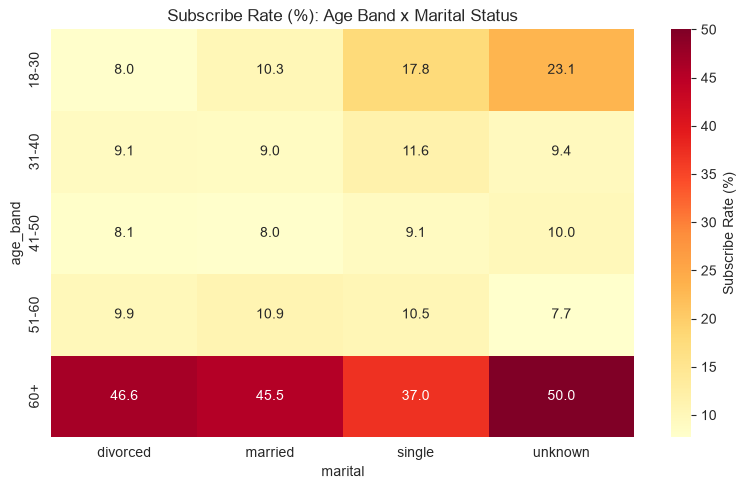

In [54]:
pivot2 = df.pivot_table(
    values='y',
    index='age_band',
    columns='marital',
    aggfunc=lambda x: (x=='yes').mean()*100,
    observed=True
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot2.round(1), annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label':'Subscribe Rate (%)'})
plt.title('Subscribe Rate (%): Age Band x Marital Status')
plt.tight_layout()
plt.savefig('subscribe rate (%) age_band versus marital_status', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
combo3 = df.groupby(['education', 'job'], observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()

reliable_combo3 = combo3[combo3['group_size'] >= 100].sort_values('subscribe_rate', ascending=False)
print(reliable_combo3.head(15).to_string(index=False))

          education        job  subscribe_rate  group_size
            unknown    student       34.355828         163
        high.school    student       31.805158         349
           basic.4y    retired       30.703259         583
professional.course    retired       23.404255         235
  university.degree    retired       23.297491         279
        high.school    retired       22.846442         267
  university.degree    student       20.000000         165
            unknown management       16.393443         122
            unknown     admin.       15.573770         244
  university.degree   services       15.243902         164
  university.degree unemployed       14.901961         255
           basic.4y unemployed       14.678899         109
professional.course unemployed       14.492754         138
  university.degree     admin.       14.356699        5635
           basic.9y unemployed       14.285714         182


In [15]:
combo4 = df.groupby(['default', 'age_band'], observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()

reliable_combo4 = combo4[combo4['group_size'] >= 100].sort_values('subscribe_rate', ascending=False)
print(reliable_combo4.to_string(index=False))

default age_band  subscribe_rate  group_size
     no      60+       45.073892         812
     no    18-30       16.086753        6409
     no    51-60       13.446830        4053
     no    31-40       10.664559       13287
     no    41-50        9.906463        7056
unknown    18-30        5.842391         736
unknown    31-40        5.528209        2641
unknown    51-60        5.005056        1978
unknown    41-50        3.843416        2810


             subscribe_rate  group_size
poutcome                               
success               65.38        1326
failure               13.90        4123
nonexistent            8.88       34424


C:\Users\91628\AppData\Local\Temp\ipykernel_41536\1192961525.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=poutcome_rate.index, y=poutcome_rate['subscribe_rate'], palette='viridis')


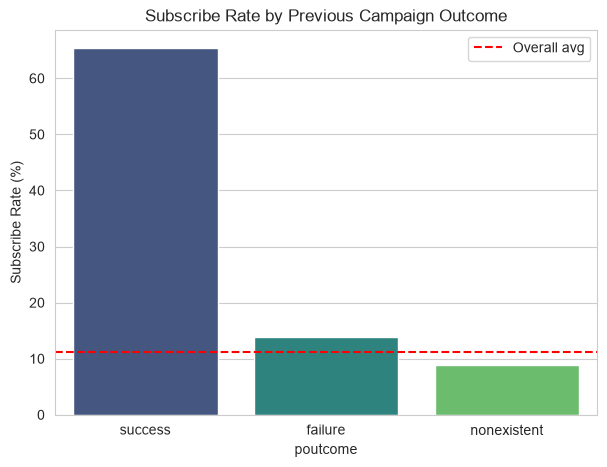

In [56]:
poutcome_rate = df.groupby('poutcome')['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).sort_values('subscribe_rate', ascending=False)
print(poutcome_rate.round(2))

plt.figure(figsize=(7,5))
sns.barplot(x=poutcome_rate.index, y=poutcome_rate['subscribe_rate'], palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Previous Campaign Outcome')
plt.axhline(11.27, color='red', linestyle='--', label='Overall avg')
plt.legend()
plt.savefig('subscribe rate by previous campaign outcome', dpi=300, bbox_inches='tight')
plt.show()

          subscribe_rate  group_size
campaign                            
1                  12.98       17072
2                  11.51       10241
3                  10.82        5166
4                   9.55        2565
5                   7.56        1560
6                   7.68         951
7                   6.09         608
8                   4.15         386
9                   6.32         269
10                  4.65         215


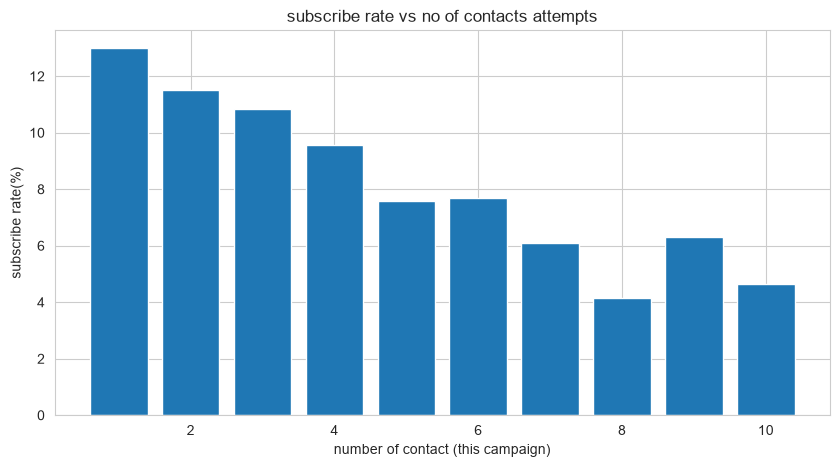

In [57]:
campaign_rate=df.groupby('campaign')['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'    
)
realible_campaign_rate=campaign_rate[campaign_rate['group_size']>=50].head(10)
print(realible_campaign_rate.round(2))

plt.figure(figsize=(10,5))
plt.bar(realible_campaign_rate.index,realible_campaign_rate['subscribe_rate'])
plt.xlabel('number of contact (this campaign)')
plt.ylabel('subscribe rate(%)')
plt.title('subscribe rate vs no of contacts attempts')
plt.savefig('subscribe rate vs no of contacts attempts', dpi=300, bbox_inches='tight')
plt.show()

       subscribe_rate  group_size
month                            
mar             50.94       532.0
apr             20.35      2565.0
may              6.50     13303.0
jun             10.59      5081.0
jul              9.03      6975.0
aug             10.55      5989.0
sep             44.69       546.0
oct             43.91       690.0
nov             10.10      4018.0
dec             48.85       174.0


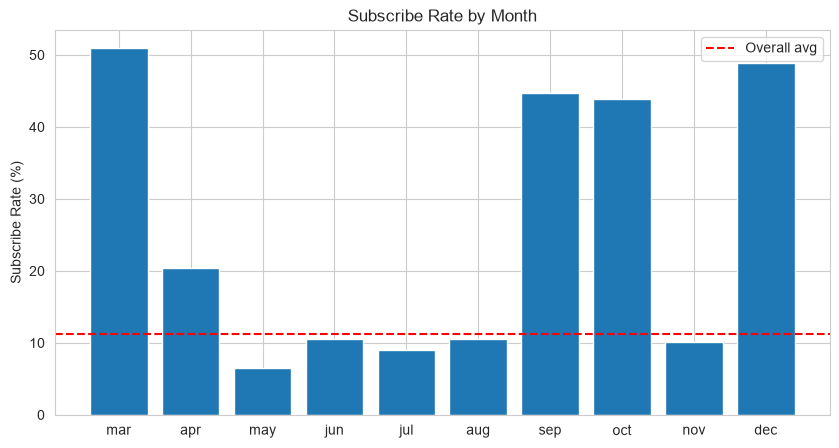

In [58]:
month_order=['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate=df.groupby('month')['y'].agg(
    subscribe_rate=lambda x:(x=='yes').mean()*100,
    group_size='count'
).reindex(month_order).dropna()
print(month_rate.round(2))


plt.figure(figsize=(10,5))
plt.bar(month_rate.index, month_rate['subscribe_rate'])
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Month')
plt.axhline(11.27, color='red', linestyle='--', label='Overall avg')
plt.legend()
plt.savefig('subscribe rate by month', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
print(df.groupby('y')['duration'].mean())

y
no     220.868079
yes    553.256090
Name: duration, dtype: float64


In [41]:
# Extreme campaign (contact attempt) outliers
print("Top 10 highest contact-attempt customers:")
print(df.nlargest(10, 'campaign')[['campaign','y']].to_string(index=False))
print()
print(f"Subscribe rate for campaign >= 20: {(df[df['campaign']>=20]['y']=='yes').mean()*100:.2f}%")
print(f"Subscribe rate for campaign < 20:  {(df[df['campaign']<20]['y']=='yes').mean()*100:.2f}%")

Top 10 highest contact-attempt customers:
 campaign  y
       43 no
       43 no
       42 no
       42 no
       41 no
       40 no
       40 no
       39 no
       37 no
       35 no

Subscribe rate for campaign >= 20: 0.54%
Subscribe rate for campaign < 20:  11.33%


In [42]:
# Extreme duration outliers
print("Top 10 longest calls:")
print(df.nlargest(10, 'duration')[['duration','y']].to_string(index=False))

Top 10 longest calls:
 duration   y
     4918  no
     4199 yes
     3785  no
     3643 yes
     3631 yes
     3509  no
     3422  no
     3366  no
     3322  no
     3284  no


In [43]:
eco_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df['y_num'] = (df['y'] == 'yes').astype(int)

correlations = {c: df[c].corr(df['y_num']) for c in eco_cols}
for c, v in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{c:15s}: {v:+.3f}")

nr.employed    : -0.353
euribor3m      : -0.306
emp.var.rate   : -0.297
cons.price.idx : -0.136
cons.conf.idx  : +0.055
